In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Exercício 1

Todo número real $x \in [0,1]$ pode ser representado, ou aproximado, por meio de uma **decomposição binária**. Nessa representação, utilizamos apenas os dígitos 0 e 1.

Considerando os primeiros $D$ dígitos binários, podemos escrever

$$
x = \frac{b_1}{2} + \frac{b_2}{2^2} + \frac{b_3}{2^3} + \cdots + \frac{b_D}{2^D},
$$

em que cada $b_i \in \{0,1\}$.

Por exemplo, o número binário $0.101_2$ corresponde, na base decimal, a

$$
0.101_2
=
1\cdot\frac{1}{2}
+
0\cdot\frac{1}{2^2}
+
1\cdot\frac{1}{2^3}
=
0.625.
$$

Assim, ao gerar aleatoriamente uma sequência de zeros e uns, podemos utilizá-la como os dígitos de uma expansão binária e, dessa forma, construir números aleatórios no intervalo $[0,1]$.


Utilizando a função `np.random.choice`, gere uma sequência de tamanho $D$ composta por dígitos 0 ou 1.

1. Utilizando essa sequência e um laço `for`, construa um número aleatório entre 0 e 1 a partir de sua decomposição binária, conforme descrito acima.

2. Utilizando a função `np.arange`, repita o procedimento do item anterior **sem utilizar um laço `for`**. Faça o cálculo por meio de operações vetorizadas, utilizando a multiplicação termo a termo entre os dígitos binários e as respectivas potências de $1/2$.

3. Utilizando o procedimento vetorizado desenvolvido no item 2, gere uma amostra de tamanho $N$ de números aleatórios no intervalo $[0,1]$. Em seguida, gere outra amostra de mesmo tamanho utilizando a função `np.random.uniform`. Compare as distribuições das duas amostras por meio de histogramas e discuta se o procedimento baseado na decomposição binária produz resultados compatíveis com uma distribuição uniforme.

4. Repita o passo 3 várias vezes com diferentes valores de $D$ e comente qual o efeito de aumentar ou diminuir $D$.

In [25]:
D = 1000
moedas = np.random.choice((0,1), size = D)

In [26]:
valor = 0
for i, dado in enumerate(moedas):
    valor += dado/2**(i+1)
print(valor)

0.5767134843012544


In [28]:
N = 10000
valores = []
for _ in range(N):
    moedas = np.random.choice((0,1), size = D)
    potencias = np.arange(1,D + 1)
    valor = np.sum(moedas * 0.5**potencias)
    valores.append(valor)
valores = np.array(valores)
uni = np.random.uniform(size = N)


(array([ 977.,  988., 1005.,  957., 1012., 1076.,  990., 1060.,  933.,
        1002.]),
 array([1.26666320e-04, 1.00109330e-01, 2.00091995e-01, 3.00074659e-01,
        4.00057323e-01, 5.00039987e-01, 6.00022651e-01, 7.00005315e-01,
        7.99987979e-01, 8.99970643e-01, 9.99953307e-01]),
 <BarContainer object of 10 artists>)

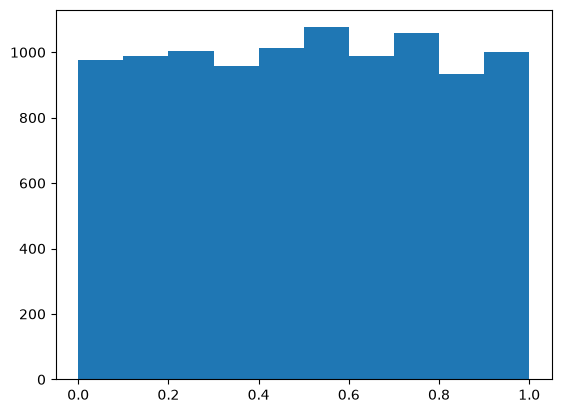

In [29]:
plt.hist(uni)

(array([1007.,  976.,  991., 1026.,  981., 1029.,  976., 1016., 1020.,
         978.]),
 array([4.38322154e-06, 9.99999477e-02, 1.99995512e-01, 2.99991077e-01,
        3.99986641e-01, 4.99982206e-01, 5.99977770e-01, 6.99973335e-01,
        7.99968899e-01, 8.99964464e-01, 9.99960028e-01]),
 <BarContainer object of 10 artists>)

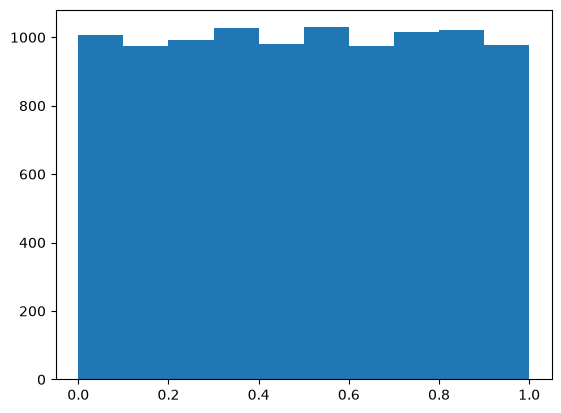

In [30]:
plt.hist(valores)

#### Ambos os resultados se assimilaram a uma uniforme!, pois a decomposição binária consegie gerar numeros bem aleatorios entre 0 e 1, e a uniforme ja faz isso sozinha

(array([662., 597., 653., 565., 614., 633., 598., 659., 642., 618., 657.,
        647., 596., 650., 572., 637.]),
 array([0.        , 0.05859375, 0.1171875 , 0.17578125, 0.234375  ,
        0.29296875, 0.3515625 , 0.41015625, 0.46875   , 0.52734375,
        0.5859375 , 0.64453125, 0.703125  , 0.76171875, 0.8203125 ,
        0.87890625, 0.9375    ]),
 <BarContainer object of 16 artists>)

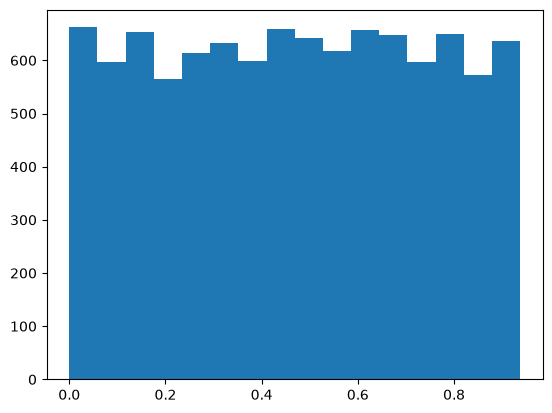

In [42]:
D = 4
valores = []
for _ in range(N):
    moedas = np.random.choice((0,1), size = D)
    potencias = np.arange(1,D + 1)
    valor = np.sum(moedas * 0.5**potencias)
    valores.append(valor)
valores = np.array(valores)
plt.hist(valores, bins=16)

(array([ 991., 1040.,  987.,  986.,  978.,  991., 1031., 1028., 1003.,
         965.]),
 array([2.03784356e-04, 1.00173465e-01, 2.00143147e-01, 3.00112828e-01,
        4.00082509e-01, 5.00052190e-01, 6.00021871e-01, 6.99991552e-01,
        7.99961233e-01, 8.99930914e-01, 9.99900595e-01]),
 <BarContainer object of 10 artists>)

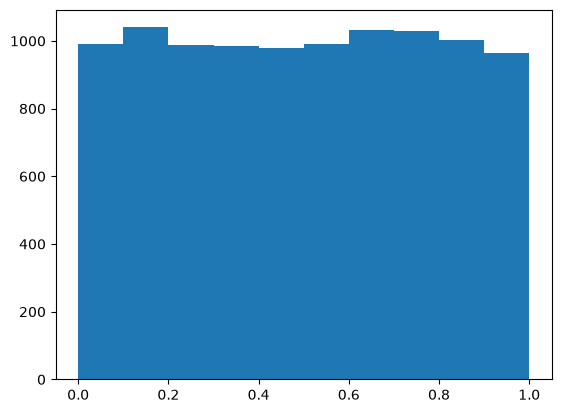

In [34]:
D = 1000
valores = []
for _ in range(N):
    moedas = np.random.choice((0,1), size = D)
    potencias = np.arange(1,D + 1)
    valor = np.sum(moedas * 0.5**potencias)
    valores.append(valor)
valores = np.array(valores)
plt.hist(valores)

#### Nesse caso, as variáveis conseguem assumir apenas $2^D$ valores

# Exercício 2 — Simulação de variáveis aleatórias a partir da distribuição uniforme

Apesar de o exercício anterior mostrar como podemos gerar variáveis uniformes em $[0,1]$ a partir de lançamentos de moedas, a partir de agora, e ao longo do curso, assumiremos que o único mecanismo de geração de números aleatórios disponível é a geração de variáveis uniformes no intervalo $[0,1]$.

Neste exercício, vamos utilizar variáveis uniformes para simular algumas das variáveis aleatórias discretas vistas em sala.

A ideia fundamental será transformar uma variável

$$
U \sim \text{Uniforme}(0,1)
$$

em outra variável aleatória por meio de uma função apropriada.

Em todos os itens, considere uma amostra de tamanho $N$.

In [43]:
N = 1000

## 1. Gerando a amostra uniforme

Utilizando `np.random.uniform`, gere uma amostra

$$
U_1,\ldots,U_N
$$

de variáveis aleatórias independentes com distribuição uniforme em $[0,1]$.

Essa será a única fonte de aleatoriedade utilizada nos itens seguintes.

In [150]:
np.random.seed(61)
U = np.random.uniform(size = N)

## 2. Variável Bernoulli

Considere uma variável aleatória Bernoulli com parâmetro $p$, isto é,

$$
P(X=1)=p
\qquad \text{e} \qquad
P(X=0)=1-p.
$$

Utilizando a amostra uniforme gerada no item anterior:

1. Gere uma amostra Bernoulli utilizando um `for` e uma estrutura `if/else`.

2. Crie uma função `f` que transforme valores uniformes em valores `0` ou `1` de acordo com o parâmetro $p$. Em seguida, aplique diretamente essa função à amostra uniforme, isto é, `f(amostra)`.

3. Calcule a média e a variância da amostra Bernoulli obtida e compare-as com os valores teóricos

$$
\mathbb{E}[X]=p
\qquad \text{e} \qquad
\operatorname{Var}(X)=p(1-p).
$$

(array([711.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 289.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

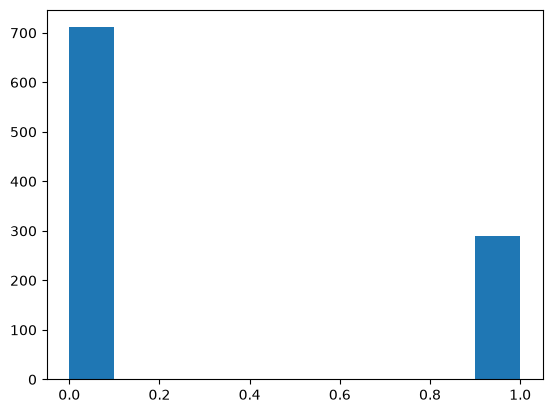

In [151]:
# 1
Ber = []
p = 0.3
for x in U:
    Ber.append(1 if x < p else 0)
plt.hist(Ber)

In [152]:
def bernoulli(amostra, p):
    return (amostra < p).astype(int)
Ber2 = bernoulli(U, p)

In [153]:
print(f'{"Bernoulli" :<15}{"Esperança" :<15}{"Variância" :<15}')
print(f'{"Bernoulli 1":<15}{np.mean(Ber):<15}{np.var(Ber):.2f}')
print(f'{"Bernoulli 2":<15}{np.mean(Ber2):<15}{np.var(Ber2):.2f}')
print(f'{"Teórica":<15}{p:<15}{p*(1-p):.2f}')

Bernoulli      Esperança      Variância      
Bernoulli 1    0.289          0.21
Bernoulli 2    0.289          0.21
Teórica        0.3            0.21


## 3. Lançamento de um dado justo

Considere um dado justo de seis faces, de modo que

$$
P(X=k)=\frac{1}{6}, \qquad k=1,\ldots,6.
$$

Utilizando a amostra uniforme gerada no item 1:

1. Gere uma amostra de lançamentos do dado utilizando um `for` e uma estrutura `if/elif/else`.

2. Crie uma função `f` que transforme valores uniformes em valores de `1` a `6`. Em seguida, aplique diretamente a função à amostra uniforme, isto é, `f(amostra)`.

3. Você consegue encontrar uma forma mais simples de fazer essa transformação, sem utilizar `if/elif/else`? Pense no que acontece ao multiplicar um valor uniforme por 6 e considerar apenas sua parte inteira.

4. Calcule a frequência relativa de cada face e compare-a com o valor teórico $1/6$.

5. Calcule a média e a variância da amostra e compare-as com os valores teóricos: $\mathbb{E}[X], \operatorname{Var}(X).$ Você pode calcular usando a fórmula $\operatorname{Var}(X) = \mathbb{E}[X^2] - \mathbb{E}[X]^2$.

6. Repita o procedimento anterior para um dado viciado com probabilidades

$$
P(X=1)=0.05,\quad
P(X=2)=0.10,\quad
P(X=3)=0.15,
$$

$$
P(X=4)=0.20,\quad
P(X=5)=0.20,\quad
P(X=6)=0.30.
$$

Construa uma função `f` que transforme a amostra uniforme em lançamentos desse dado. Compare as frequências relativas obtidas com as probabilidades teóricas acima e compare também a média e a variância amostrais com os valores teóricos.


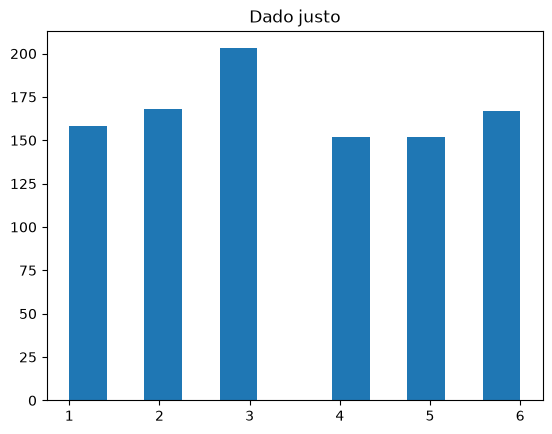

In [154]:
dados = []
for x in U:
    if x < 1/6:
        dados.append(1)
    elif x < 2/6:
        dados.append(2)
    elif x < 3/6:
        dados.append(3)
    elif x < 4/6:
        dados.append(4)
    elif x < 5/6:
        dados.append(5)
    else:
        dados.append(6)
plt.hist(dados, bins = 12)
plt.title('Dado justo')
plt.show()

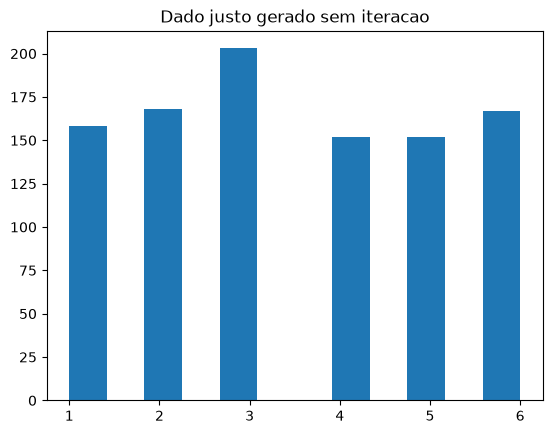

In [155]:
def dado (amostra):
    return np.ceil(amostra * 6)

dados2 = dado(U)

plt.hist(dados2, bins = 12)
plt.title('Dado justo gerado sem iteracao')
plt.show()

#### Aqui já foi gerado as amostras sem a iteração, multiplicando por 6 e pegando o valor inteiro mais alto, para ficar em {1,2,3,4,5,6}

In [156]:
# 4
faces, freqs = np.unique(dados2, return_counts=True)
print(f'A frequência esperada para cada face é de {1/6:.3f}')
for face, freq in zip(faces, freqs):
    print(f'Frequência de {face}: {freq/N:.3f} | Desvio de {1/6-freq/N:>6.3f}')

A frequência esperada para cada face é de 0.167
Frequência de 1.0: 0.158 | Desvio de  0.009
Frequência de 2.0: 0.168 | Desvio de -0.001
Frequência de 3.0: 0.203 | Desvio de -0.036
Frequência de 4.0: 0.152 | Desvio de  0.015
Frequência de 5.0: 0.152 | Desvio de  0.015
Frequência de 6.0: 0.167 | Desvio de -0.000


In [157]:
# 5
E = np.sum(np.arange(1,7))/6
print(f'Esperança teórica: {E}')
Xbarra = np.mean(dados2)
print(f'Média amostral: {Xbarra}')
Var = np.arange(1,7)
Var = Var ** 2
Var = Var / 6
Var = np.sum(Var) - E**2
print(f'Variância teórica: {Var}')
print(f'Variância amostra: {np.var(dados2)}')

Esperança teórica: 3.5
Média amostral: 3.473
Variância teórica: 2.916666666666668
Variância amostra: 2.8392709999999997


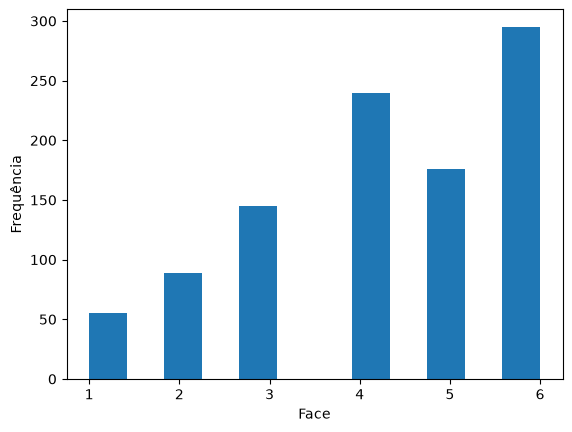

In [169]:
def dado_injusto(amostra):
    return np.where(amostra < 0.05, 1,
           np.where(amostra < 0.15, 2,
           np.where(amostra < 0.30, 3,
           np.where(amostra < 0.50, 4,
           np.where(amostra < 0.70, 5, 6)))))

dinj = dado_injusto(U)
plt.hist(dinj, bins = 12)
plt.xlabel("Face")
plt.ylabel("Frequência")
plt.show()

In [181]:
faces, freqs = np.unique(dinj, return_counts=True)
freqs_esperadas = [0.05,0.1,0.15,0.2,0.2,0.3]
for face, freq, freq_esperada in zip(faces, freqs, freqs_esperadas):
    print(f'Frequência de {face}: {freq/N:.3f} | Frequência esperada: {freq_esperada:> 5} | Desvio de {freq_esperada- freq/N:>6.3f}')

Frequência de 1: 0.055 | Frequência esperada:  0.05 | Desvio de -0.005
Frequência de 2: 0.089 | Frequência esperada:   0.1 | Desvio de  0.011
Frequência de 3: 0.145 | Frequência esperada:  0.15 | Desvio de  0.005
Frequência de 4: 0.240 | Frequência esperada:   0.2 | Desvio de -0.040
Frequência de 5: 0.176 | Frequência esperada:   0.2 | Desvio de  0.024
Frequência de 6: 0.295 | Frequência esperada:   0.3 | Desvio de  0.005


## 4. Distribuição Binomial

Podemos interpretar uma variável aleatória binomial pensando em lançamentos de uma moeda. Suponha que lançamos uma moeda $n$ vezes, de forma independente, e que a probabilidade de obter **cara** em cada lançamento seja $p$.

Se contarmos o número total de caras obtidas nesses $n$ lançamentos, esse número segue uma distribuição binomial:

$$
X \sim \mathrm{Binomial}(n,p).
$$

Assim, uma variável binomial nada mais é do que a soma de $n$ variáveis Bernoulli independentes:

$$
X = X_1 + \cdots + X_n,
\qquad
X_i \sim \mathrm{Bernoulli}(p),
$$

onde $X_i=1$ representa uma cara e $X_i=0$ representa uma coroa.

1. Utilizando o procedimento desenvolvido anteriormente para gerar variáveis Bernoulli, gere uma amostra de tamanho $N$ de variáveis com distribuição $\mathrm{Binomial}(n,p)$.

2. Calcule a média e a variância da amostra e compare-as com os valores teóricos

$$
\mathbb{E}[X]=np
\qquad \text{e} \qquad
\operatorname{Var}(X)=np(1-p).
$$

3. Gere uma segunda amostra de tamanho $N$ utilizando `np.random.binomial` com os mesmos parâmetros $n$ e $p$. Compare as duas amostras por meio de histogramas.


## 5. Distribuição Multinomial

A distribuição multinomial é uma generalização da distribuição binomial.

Na distribuição binomial, realizamos $n$ lançamentos de uma moeda e contamos quantas vezes ocorreu um dos dois resultados possíveis. Na distribuição multinomial, fazemos a mesma ideia, mas com $k$ resultados possíveis.

Por exemplo, considere um dado de $k$ lados, em que a face $i$ aparece com probabilidade $p_i$, com

$$
p_1+\cdots+p_k=1.
$$

Após $n$ lançamentos, definimos

$$
X=(X_1,\ldots,X_k),
$$

onde $X_i$ representa o número de vezes que a face $i$ apareceu. Nesse caso,

$$
X \sim \mathrm{Multinomial}(n,p_1,\ldots,p_k),
$$

e

$$
X_1+\cdots+X_k=n.
$$

Considere agora um dado de **4 lados** com probabilidades

$$
P(X=1)=0.10,\qquad
P(X=2)=0.20,\qquad
P(X=3)=0.30,\qquad
P(X=4)=0.40.
$$

1. Utilizando o procedimento desenvolvido anteriormente, realize $n$ lançamentos desse dado e conte quantas vezes cada uma das quatro faces apareceu.

2. Repita esse experimento $N$ vezes, gerando uma amostra de tamanho $N$ de vetores com distribuição multinomial.

3. Para cada face $i$, calcule a média amostral de $X_i$ e compare-a com o valor teórico

$$
\mathbb{E}[X_i]=np_i.
$$

4. Gere uma segunda amostra utilizando `np.random.multinomial` com os mesmos parâmetros e compare os resultados obtidos pelos dois métodos.

5. Verifique que, em cada realização, a soma das contagens das $k$ faces é igual a $n$.

6. Para cada face $i$, calcule a variância amostral de $X_i$ e compare-a com

$$
\operatorname{Var}(X_i)=np_i(1-p_i).
$$

7. Escolha duas faces distintas e calcule a covariância amostral entre suas contagens. Compare-a com

$$
\operatorname{Cov}(X_i,X_j)=-np_ip_j.
$$

Interprete o sinal negativo dessa covariância.